<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/3_Analisis_y_visualizacion_datos/7_Dataton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# 🏦 **DATATÓN: El Misterio de la Fuga de Clientes**
## **Misión de consultoría para la Junta Directiva del Banco Externado**
---

## 📄 Contexto del negocio

**Cliente:** Junta Directiva del Banco Externado

**Su rol:** Equipo de Analistas de Datos (*Data Scientists*)

**Tiempo límite:** hasta el final de la clase

El Banco Externado se enfrenta a una crisis sin precedentes. En el último trimestre, la tasa de abandono de clientes (**fuga**) se disparó. Cada cliente que cierra sus cuentas representa una pérdida enorme en valor presente neto para la entidad. La Junta Directiva necesita entender **quiénes se están yendo y por qué**, para diseñar una política de retención urgente.

El departamento de Ingeniería de Sistemas logró extraer la información de los clientes, pero —como suele ocurrir en la vida real— **los datos son un desastre**: vienen en dos archivos separados, con valores nulos, formatos extraños, registros repetidos y errores de digitación.

**Su misión:** limpiar, integrar, transformar y explorar estos datos para presentar un diagnóstico económico a la Junta Directiva antes de que cierre la bolsa.

## 💾 Diccionario de datos

**1. `banco_clientes.csv` — Información demográfica**

| Columna | Descripción |
|---|---|
| `ID_Cliente` | Identificador único del usuario. |
| `Edad` | Edad del cliente en años. |
| `Ingreso_Mensual` | Ingresos mensuales estimados en pesos. |
| `Genero` | Género del cliente (digitado a mano por el asesor). |
| `Ciudad` | Ciudad de residencia (digitada a mano por el asesor). |
| `Fecha_Ingreso` | Fecha de vinculación al banco, **guardada como texto** en formato `DD/MM/AAAA`. |

**2. `banco_transacciones.csv` — Información de comportamiento**

| Columna | Descripción |
|---|---|
| `ID_Cliente` | Identificador único del usuario. **Ojo:** el core bancario exporta parte de los IDs con el prefijo del sistema (`CLI-00145`). |
| `Saldo_Cuenta` | Dinero promedio en la cuenta. |
| `Cant_Productos` | Número de productos activos (tarjetas, créditos, CDT, etc.). |
| `Fuga_Ultimo_Mes` | **Variable objetivo.** `1` si el cliente abandonó el banco, `0` si continúa activo. |

## 📋 Instrucciones generales

- Trabajen en **equipos de 2 personas**, en este mismo notebook.
- Completen el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Pueden añadir todas las celdas que necesiten.
- **No modifiquen** la celda de verificación (la última celda de código del notebook).
- Usen **exactamente** los nombres de variables que pide cada enunciado: la verificación automática los busca por nombre.
- Los retos son **acumulativos**: el reto 4 usa el resultado del reto 2. Si un punto sale ❌, revísenlo antes de seguir, porque arrastra a los siguientes.
- Al final, ejecuten la **celda de verificación**: les dirá qué porcentaje llevan y en cuál punto exacto se equivocaron. Pueden ejecutarla todas las veces que quieran mientras trabajan.
- Los puntos de **análisis escrito** no dan puntaje automático: los revisará posteriormente la profesora.

### ✅ Checklist de nombres exactos

La verificación busca estas variables. Consérvenlas escritas tal cual:

| Reto | Variables |
|---|---|
| 1 | `RUTA_DATOS`, `df_clientes`, `df_transacciones`, `n_duplicados`, `df_banco`, `dim_banco` |
| 2 | `mediana_edad`, `mediana_ingreso`, `generos_finales`, `ciudades_finales`, `nulos_restantes`, `edad_maxima` |
| 3 | `q1_saldo`, `q3_saldo`, `iqr_saldo`, `limite_inferior_saldo`, `limite_superior_saldo`, `n_outliers_saldo`, `decision_outliers` |
| 4 | `Ingreso_Anual`, `Antiguedad_Anios`, `Ratio_Ahorro` (columnas), `ratio_por_fuga`, `resumen_saldo` |
| 5 | `Segmento_Ingreso` (columna), `conteo_segmentos`, `fuga_por_segmento` |
| 6 | `tasa_fuga_productos`, `ingreso_por_fuga`, `tabla_ejecutiva`, `matriz_correlacion`, `correlacion_con_fuga` |
| 7 | `pitch_economico`, `recomendaciones` |
| 8 | `df_ml` |

---
## ⚙️ Preparación del entorno

Ejecuta las dos celdas siguientes **sin modificarlas**.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Que muestre todas las columnas
pd.options.display.max_columns = None
# En los dataframes, mostrar los float con dos decimales
pd.options.display.float_format = '{:,.2f}'.format

### 📂 Antes de empezar: llevar los datos a Colab

Colab arranca con una máquina vacía, así que los dos archivos (`banco_clientes.csv` y `banco_transacciones.csv`) tienen que quedar al alcance del notebook. Hay dos formas; **elijan la que prefieran**:

| Cómo | Qué hacer | Ojo |
|---|---|---|
| **Panel de archivos** | Abrir el ícono de carpeta 📁 de la barra izquierda y arrastrar los dos CSV. | Es la más rápida, pero **los archivos se pierden** si el entorno se reinicia y toca volver a subirlos. |
| **Google Drive** | Guardar los CSV en una carpeta de su Drive y ejecutar `from google.colab import drive` y `drive.mount('/content/drive')`. | Los archivos no se pierden si el entorno se reinicia. |

---
# 🔍 **Reto 1: Auditoría e Integración de la Información**

Antes de analizar nada hay que saber **qué tan sucios están los datos** y unir las dos bases.

**1.1 Carga y auditoría.** Importa los dos archivos en `df_clientes` y `df_transacciones` y revísalos con `.info()`. Fíjate en el tipo de dato de cada columna: hay al menos uno que no es el que debería ser.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_clientes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataton/banco_clientes.csv')
df_transacciones = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataton/banco_transacciones.csv')

df_clientes.info()
df_transacciones.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Cliente       3060 non-null   int64  
 1   Edad             3009 non-null   float64
 2   Ingreso_Mensual  2957 non-null   float64
 3   Genero           3060 non-null   object 
 4   Ciudad           3060 non-null   object 
 5   Fecha_Ingreso    3060 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 143.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2550 entries, 0 to 2549
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Cliente       2550 non-null   object 
 1   Saldo_Cuenta     2550 non-null   float64
 2   Cant_Productos   2550 non-null   int64  
 3   Fuga_Ultimo_Mes  2550 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 79.8+ KB


**1.2 Registros repetidos.** La extracción del sistema se corrió dos veces y algunos clientes quedaron duplicados.

1. Cuenta cuántas **filas completamente duplicadas** hay en `df_clientes` y guarda ese número (como entero) en `n_duplicados`.
2. Elimina los duplicados de `df_clientes`, conservando la primera aparición de cada cliente.

In [ ]:
n_duplicados = df_clientes.duplicated().sum()
df_clientes.drop_duplicates(inplace=True)

n_duplicados


np.int64(60)

**1.3 La llave no coincide.** Si intentas unir las dos tablas ahora mismo, pandas te lanzará un error parecido a este:

```
ValueError: You are trying to merge on int64 and object columns for key 'ID_Cliente'
```

Eso ocurre porque en `df_transacciones` el `ID_Cliente` llega como **texto** (parte de los registros traen el prefijo `CLI-`), mientras que en `df_clientes` es un número. No se puede cruzar una tabla por una llave de tipo texto con otra de tipo número.

Deja el `ID_Cliente` de `df_transacciones` como número entero, quitándole el prefijo `CLI-` y los ceros de relleno.

> 💡 `.astype(str)` → `.str.replace('CLI-', '', regex=False)` → `.astype(int)`

In [ ]:
df_transacciones['ID_Cliente'] = df_transacciones['ID_Cliente'].str.replace('CLI-', '').astype(int)

df_transacciones.head()


,ID_Cliente,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes
0,2677,"1,531.18",4,0
1,2018,"7,350.85",4,0
2,779,"16,538.90",4,0
3,1863,"1,242.22",2,0
4,1305,"1,029.13",5,0


**1.4 La unión.** Une las dos tablas usando `ID_Cliente` como llave y guarda el resultado en `df_banco`.

**No pueden perderse** los clientes que están en la base demográfica pero no tienen transacciones recientes: ese grupo es justamente el más sospechoso de haberse fugado. *(Pista: piensa qué tipo de `merge` conserva todas las filas de la tabla izquierda.)*

Luego:
- Guarda las dimensiones del resultado en `dim_banco` (usa `df_banco.shape`).
- Imprime esas dimensiones y muestra las 3 primeras filas.

In [ ]:
df_banco = df_clientes.merge(df_transacciones, on='ID_Cliente', how='left')
dim_banco = df_banco.shape

dim_banco


(3000, 9)

---
# 🧹 **Reto 2: Limpieza**

Los modelos de *Machine Learning* odian la basura. Hay que dejar la base impecable.

**2.1 Estandarizar `Genero`.** La columna fue llenada a mano y tiene inconsistencias (`M`, `m`, `F`, `f`, `Otro`). Unifícala para que existan **exactamente** estas 3 categorías, escritas así:

`Femenino`, `Masculino`, `Otro`

Después, guarda en `generos_finales` la lista **ordenada alfabéticamente** de las categorías que quedaron. *(Pista: `sorted(...)` sobre los valores únicos.)*

In [ ]:
df_banco['Genero'] = df_banco['Genero'].str.upper().replace(
    {'F':'Femenino', 'M':'Masculino', 'OTRO':'Otro'}
)
generos_finales = sorted(df_banco['Genero'].unique())

generos_finales


['Femenino', 'Masculino', 'Otro']

**2.2 Estandarizar `Ciudad`.** Mismo problema, pero peor: hay espacios sobrantes, mayúsculas y tildes faltantes (`' Bogotá '`, `'bogota'`, `'BOGOTA'`...). Unifícala para que existan **exactamente** estas 4 categorías, escritas así:

`Barranquilla`, `Bogotá`, `Cali`, `Medellín`

Guarda en `ciudades_finales` la lista ordenada alfabéticamente de las categorías que quedaron.

> 💡 Encadena `.str.strip()` (quita espacios), `.str.title()` (deja solo la primera letra en mayúscula) y un `.replace({...})` para las versiones sin tilde.

In [ ]:
df_banco['Ciudad'] = df_banco['Ciudad'].str.strip().str.title().replace(
    {'Bogota':'Bogotá', 'Medellin':'Medellín'}
)
ciudades_finales = sorted(df_banco['Ciudad'].unique())

ciudades_finales


['Barranquilla', 'Bogotá', 'Cali', 'Medellín']

**2.3 Valores nulos.** Revisa cuántos nulos hay por columna con `.isna().sum()` y luego impútalos **en este orden y con estos criterios**:

| Columna | Imputar con | Por qué |
|---|---|---|
| `Edad` | la **mediana** (guárdala en `mediana_edad`) |  |
| `Ingreso_Mensual` | la **mediana** (guárdala en `mediana_ingreso`) |  |
| `Saldo_Cuenta` | `0` | Si no aparece en la base transaccional, el cliente no tiene saldo con el banco. |
| `Cant_Productos` | `0` | Mismo razonamiento: no tiene productos activos. |
| `Fuga_Ultimo_Mes` | `1` |  |

Al terminar, guarda en `nulos_restantes` el total de nulos que quedan en toda la base (debe ser `0`).

> ⚠️ Calcula las dos medianas **antes** de imputar y guárdalas en `mediana_edad` y `mediana_ingreso`: las vas a volver a usar en el punto 2.4.

In [ ]:
df_banco.isna().sum()


,0
ID_Cliente,0
Edad,50
Ingreso_Mensual,100
Genero,0
Ciudad,0
Fecha_Ingreso,0
Saldo_Cuenta,450
Cant_Productos,450
Fuga_Ultimo_Mes,450


In [ ]:
mediana_edad = df_banco['Edad'].median()
mediana_ingreso = df_banco['Ingreso_Mensual'].median()

df_banco.fillna({
    'Edad': mediana_edad,
    'Ingreso_Mensual': mediana_ingreso,
    'Saldo_Cuenta': 0,
    'Cant_Productos': 0,
    'Fuga_Ultimo_Mes': 1
}, inplace=True)

nulos_restantes = df_banco.isna().sum().sum()

nulos_restantes


np.int64(0)

**2.4 El cliente de 150 años.** Hay un cliente con una edad imposible. Encuéntralo, y reemplaza por `mediana_edad` la edad de **todo cliente que tenga más de 100 años**.

Guarda en `edad_maxima` la edad máxima que queda en la base después de la corrección.

> 💡 Usa `.loc[condición, 'Edad'] = valor` para modificar solo las filas que cumplen la condición.

In [ ]:
df_banco.loc[df_banco['Edad'] > 100, 'Edad'] = mediana_edad
edad_maxima = df_banco['Edad'].max()

edad_maxima


80.71875339871633

📝 **Para la Junta (revisión de la profesora).** En la celda de texto siguiente, justifiquen en 3 o 4 líneas: ¿por qué la **mediana** y no la media para `Edad` e `Ingreso_Mensual`? ¿Qué habría pasado con el promedio de edad si hubieran dejado al cliente de 150 años? ¿Qué supuesto económico están haciendo al imputar `Fuga_Ultimo_Mes = 1`?

### Justificación para la Junta

La mediana es una mejor medida en este caso ya que a diferencia de la media no carga con un sezgo, la media puede estar sesgada y afectar la varianza de los datos. Si se hubiera dejado la edad de 150 años, la media se hubiera disparado y no reflejaria la realidad de los datos.


---
# 📏 **Reto 3: Outliers con criterio estadístico (regla del IQR)**

El cliente de 150 años era un error evidente. Pero en `Saldo_Cuenta` hay valores altísimos que **no** son errores: son clientes con mucho dinero. La pregunta económica es si deben tratarse como datos válidos o como anomalías.

Para decidirlo con un criterio y no "a ojo", se usa la **regla del rango intercuartílico (IQR)**: se considera atípico todo dato que esté por fuera del intervalo

$$[\;Q_1 - 1.5 \cdot IQR\;,\;\; Q_3 + 1.5 \cdot IQR\;]$$

Calcula sobre `Saldo_Cuenta` (ya limpia e imputada) y guarda en estas variables:

- `q1_saldo`: percentil 25 *(pista: `.quantile(0.25)`)*
- `q3_saldo`: percentil 75
- `iqr_saldo`: la diferencia entre ambos
- `limite_inferior_saldo` y `limite_superior_saldo`: los dos extremos de la fórmula
- `n_outliers_saldo`: cuántos clientes (entero) quedan **por fuera** de ese intervalo

Imprime los cinco valores.

In [ ]:
q1_saldo, q3_saldo = df_banco['Saldo_Cuenta'].quantile([.25, .75])
iqr_saldo = q3_saldo - q1_saldo

limite_inferior_saldo = q1_saldo - 1.5*iqr_saldo
limite_superior_saldo = q3_saldo + 1.5*iqr_saldo

n_outliers_saldo = (
    (df_banco['Saldo_Cuenta'] < limite_inferior_saldo) |
    (df_banco['Saldo_Cuenta'] > limite_superior_saldo)
).sum()

n_outliers_saldo


np.int64(226)

**3.2 La decisión.** A diferencia del cliente de 150 años, **estos saldos no se van a corregir**: un saldo de 60 millones es perfectamente posible y, de hecho, corresponde a los clientes más valiosos del banco. Recortarlos borraría justo al segmento que la Junta quiere retener.

Guarda esa decisión argumentada en una variable de texto llamada `decision_outliers` (mínimo 150 caracteres). Explica: ¿por qué un outlier *estadístico* no es lo mismo que un *error de digitación*? ¿Qué se perdería si los elimináramos?

```python
decision_outliers = """Escriban aquí su argumento..."""
```

In [ ]:
decision_outliers = """Un outlier estadístico no necesariamente es un error. Los saldos altos son plausibles y pueden corresponder a clientes de alto valor. Eliminarlos distorsionaría la distribución, reduciría artificialmente el saldo promedio y eliminaría información útil para diseñar estrategias de retención."""

print(f"Longitud del argumento: {len(decision_outliers)} caracteres")


Longitud del argumento: 290 caracteres


---
# ⚙️ **Reto 4: Transformación y creación de variables**

**4.1 Ingreso anual.** Crea la columna `Ingreso_Anual` asumiendo 12 meses.

In [ ]:
df_banco['Ingreso_Anual'] = df_banco['Ingreso_Mensual'] * 12


**4.2 Antigüedad del cliente.** La columna `Fecha_Ingreso` llegó como texto, así que hoy no sirve para calcular nada.

1. Conviértela a fecha real con `pd.to_datetime(..., format='%d/%m/%Y')`.
2. Crea la columna `Antiguedad_Anios` con los años que lleva cada cliente en el banco **a la fecha de corte del informe**, que es el **1 de enero de 2026** (ya está definida abajo como `FECHA_CORTE`).
3. **Redondea la columna a 2 decimales.**

> 💡 Al restar dos fechas obtienes un `Timedelta`; `.dt.days` te da los días, y se divide entre `365.25` para pasar a años.
>
> ⚠️ Usa `FECHA_CORTE`, **no** la fecha de hoy: así el resultado es el mismo para todos los equipos.

In [ ]:
FECHA_CORTE = pd.Timestamp('2026-01-01')   # No modificar

In [ ]:
df_banco['Fecha_Ingreso'] = pd.to_datetime(df_banco['Fecha_Ingreso'], format='%d/%m/%Y')
df_banco['Antiguedad_Anios'] = ((FECHA_CORTE - df_banco['Fecha_Ingreso']).dt.days / 365.25).round(2)

df_banco[['Fecha_Ingreso','Antiguedad_Anios']].head()


,Fecha_Ingreso,Antiguedad_Anios
0,2022-05-22,3.61
1,2020-09-28,5.26
2,2021-05-21,4.62
3,2021-11-08,4.15
4,2023-11-15,2.13


**4.3 Un indicador propio: capacidad de ahorro.** El saldo en pesos no dice lo mismo para alguien que gana 1 millón que para alguien que gana 10. Lo informativo es el saldo **relativo al ingreso**.

1. Crea la columna `Ratio_Ahorro` = `Saldo_Cuenta` / `Ingreso_Mensual`.
2. Calcula el promedio de ese ratio para los que se fugaron y para los que se quedaron, y guárdalo en `ratio_por_fuga` *(pista: `groupby` sobre `Fuga_Ultimo_Mes` + `.mean()`)*.
3. Imprime el resultado y obsérvalo: ese número es una de las piezas del pitch.

In [ ]:
df_banco['Ratio_Ahorro'] = df_banco['Saldo_Cuenta'] / df_banco['Ingreso_Mensual']
ratio_por_fuga = df_banco.groupby('Fuga_Ultimo_Mes')['Ratio_Ahorro'].mean()

ratio_por_fuga


,Ratio_Ahorro
Fuga_Ultimo_Mes,
0.00,0.00
1.00,0.00


**4.4 Resumen para la Junta.** Construye una tabla agrupada llamada `resumen_saldo` con el **saldo promedio en cuenta**, agrupado por `Genero` y por `Fuga_Ultimo_Mes`.

> 💡 `df_banco.groupby([...])['...'].mean()`

In [ ]:
resumen_saldo = df_banco.groupby(['Genero','Fuga_Ultimo_Mes'])['Saldo_Cuenta'].mean()

resumen_saldo


Genero     Fuga_Ultimo_Mes
Femenino   0.00              8,350.04
           1.00                961.86
Masculino  0.00              7,577.36
           1.00                997.52
Otro       0.00              8,341.97
           1.00                827.90
Name: Saldo_Cuenta, dtype: float64

---
# 🎯 **Reto 5: Segmentación de clientes**

La Junta no puede diseñar una política para 3.000 personas una por una: necesita **segmentos**.

**5.1** Crea la columna `Segmento_Ingreso` clasificando a cada cliente según su `Ingreso_Mensual`, usando `pd.cut` con **estos cortes exactos**:

| Segmento | Ingreso mensual |
|---|---|
| `Bajo` | hasta 2.000.000 |
| `Medio` | más de 2.000.000 y hasta 5.000.000 |
| `Alto` | más de 5.000.000 |

```python
bins = [0, 2_000_000, 5_000_000, np.inf]
labels = ['Bajo', 'Medio', 'Alto']
```

Luego guarda en `conteo_segmentos` cuántos clientes hay en cada segmento *(pista: `.value_counts()`)*.

In [ ]:
df_banco['Segmento_Ingreso'] = pd.cut(
    df_banco['Ingreso_Mensual'],
    [0, 2_000_000, 5_000_000, np.inf],
    labels=['Bajo','Medio','Alto']
)

conteo_segmentos = df_banco['Segmento_Ingreso'].value_counts()
conteo_segmentos


,count
Segmento_Ingreso,
Medio,1483
Bajo,795
Alto,722


**5.2** Calcula la **tasa de fuga por segmento** y guárdala en `fuga_por_segmento`.

Como `Fuga_Ultimo_Mes` vale 0 o 1, su **promedio** dentro de cada grupo es directamente la proporción de clientes que se fugaron.

Imprime el resultado: es el hallazgo central del informe.

In [ ]:
fuga_por_segmento = df_banco.groupby(
    'Segmento_Ingreso', observed=False
)['Fuga_Ultimo_Mes'].mean()

fuga_por_segmento


,Fuga_Ultimo_Mes
Segmento_Ingreso,
Bajo,0.97
Medio,0.24
Alto,0.12


---
# 📊 **Reto 6: Que hablen los datos (EDA)**

**6.1 Fuga y número de productos.** Calcula en `tasa_fuga_productos` la tasa de fuga promedio según `Cant_Productos` y grafícala con un diagrama de barras.

> 💡 En `seaborn`, `sns.barplot(x=tasa_fuga_productos.index, y=tasa_fuga_productos.values)`.

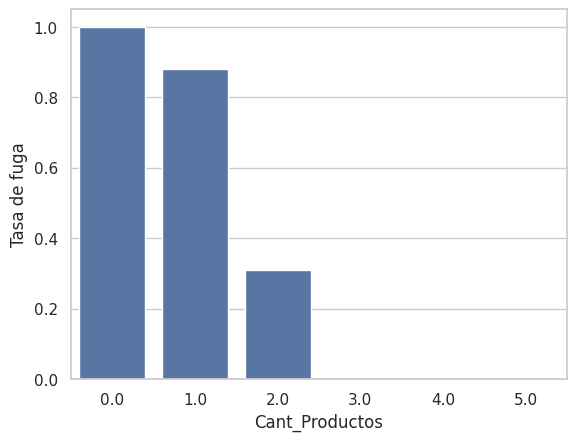

In [ ]:
tasa_fuga_productos = df_banco.groupby('Cant_Productos')['Fuga_Ultimo_Mes'].mean()

sns.barplot(x=tasa_fuga_productos.index, y=tasa_fuga_productos.values)
plt.ylabel('Tasa de fuga')
plt.show()


**6.2 Fuga e ingresos.** Calcula en `ingreso_por_fuga` el **ingreso mensual mediano** de los que se quedaron y de los que se fugaron, y construye un **boxplot** que compare las dos distribuciones.

> 💡 `sns.boxplot(data=df_banco, x='Fuga_Ultimo_Mes', y='Ingreso_Mensual')`

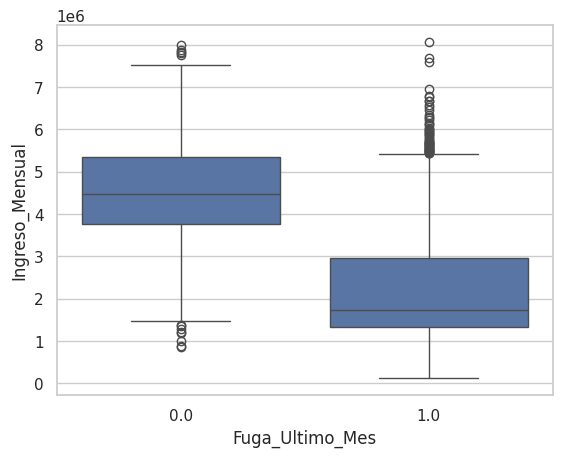

,Ingreso_Mensual
Fuga_Ultimo_Mes,
0.00,"4,476,980.86"
1.00,"1,732,029.15"


In [ ]:
ingreso_por_fuga = df_banco.groupby('Fuga_Ultimo_Mes')['Ingreso_Mensual'].median()

sns.boxplot(data=df_banco, x='Fuga_Ultimo_Mes', y='Ingreso_Mensual')
plt.show()

ingreso_por_fuga


**6.3 La tabla ejecutiva.** La Junta no lee código: lee tablas. Construye en `tabla_ejecutiva` una tabla dinámica con la **tasa de fuga** cruzando `Ciudad` (en las filas) contra `Cant_Productos` (en las columnas).

> 💡 `df_banco.pivot_table(index=..., columns=..., values=..., aggfunc='mean')`

Imprímela redondeada a 3 decimales y léela con ojo de economista: ¿la fuga es un problema de *ciudad* o un problema de *relación comercial*? ¿Hay alguna ciudad que se salga del patrón?

In [ ]:
tabla_ejecutiva = df_banco.pivot_table(
    index='Ciudad',
    columns='Cant_Productos',
    values='Fuga_Ultimo_Mes',
    aggfunc='mean'
)

tabla_ejecutiva


Cant_Productos,0.00,1.00,2.00,3.00,4.00,5.00
Ciudad,,,,,,
Barranquilla,1.00,0.77,0.23,0.00,0.00,0.00
Bogotá,1.00,0.90,0.30,0.00,0.00,0.00
Cali,1.00,0.89,0.39,0.00,0.00,0.00
Medellín,1.00,0.89,0.31,0.00,0.00,0.00


**6.4 La matriz de correlación.** Ahora midan qué tan asociada está cada variable con la fuga.

1. Calcula en `matriz_correlacion` la matriz de correlación de estas columnas, **en este orden**:

```python
columnas_numericas = ['Edad', 'Ingreso_Mensual', 'Saldo_Cuenta', 'Cant_Productos',
                      'Antiguedad_Anios', 'Ratio_Ahorro', 'Fuga_Ultimo_Mes']
```

2. Grafícala con un **heatmap**: `sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', center=0)`.
3. Guarda en `correlacion_con_fuga` la columna `Fuga_Ultimo_Mes` de esa matriz, **sin la diagonal** (quita la correlación de la fuga consigo misma, que siempre es 1) y **ordenada de menor a mayor** con `.sort_values()`.

> ⚠️ Fíjense en qué **no** entra a la matriz. `ID_Cliente` queda fuera porque es un identificador, no una variable económica: su correlación no significa nada. E `Ingreso_Anual` queda fuera porque es `Ingreso_Mensual × 12`, o sea la misma información: su correlación con el ingreso mensual es exactamente 1,0. Meter las dos es la misma trampa de multicolinealidad que van a evitar con `drop_first` en el Reto 8.

Al leer el resultado, comparen las variables de **comportamiento** (productos, saldo, ratio de ahorro) con las **demográficas** (edad, antigüedad). Y recuerden: la correlación dice dónde mirar, **no** dice qué causa qué.

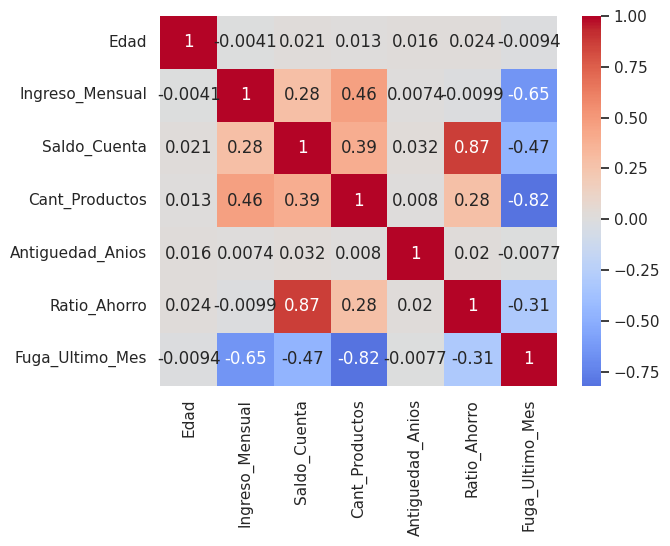

,Fuga_Ultimo_Mes
Cant_Productos,-0.82
Ingreso_Mensual,-0.65
Saldo_Cuenta,-0.47
Ratio_Ahorro,-0.31
Edad,-0.01
Antiguedad_Anios,-0.01


In [ ]:
columnas_numericas = [
    'Edad','Ingreso_Mensual','Saldo_Cuenta','Cant_Productos',
    'Antiguedad_Anios','Ratio_Ahorro','Fuga_Ultimo_Mes'
]

matriz_correlacion = df_banco[columnas_numericas].corr()

sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', center=0)
plt.show()

correlacion_con_fuga = matriz_correlacion['Fuga_Ultimo_Mes'].drop('Fuga_Ultimo_Mes').sort_values()
correlacion_con_fuga


---
# 🏆 **Reto 7: El diagnóstico para la Junta Directiva**

Este reto lo lee y lo califica la profesora.

Ya tienen toda la evidencia: la tasa de fuga por segmento, por cantidad de productos y por ciudad, el ratio de ahorro y la matriz de correlación. Ahora hay que convertir eso en un argumento.

**7.1 El pitch económico.**

Guarda en una variable de texto llamada `pitch_economico` (mínimo 500 caracteres) el diagnóstico que le presentarían a la Junta Directiva.

**No describan las gráficas** ("la barra azul es más alta"). Expliquen el **mecanismo económico** detrás:

- ¿Por qué tener más productos reduce la fuga? *(piensen en costos de cambio y en relación de largo plazo con el banco)*
- El banco, ¿está perdiendo a sus clientes más rentables o a los menos rentables? ¿Qué implica eso para el valor presente neto de la cartera?
- ¿Qué les dice la matriz de correlación sobre el tipo de variable que anticipa la fuga: las de comportamiento o las demográficas? ¿Qué consecuencia tiene eso para dónde debe mirar el banco?
- Usen las cifras que ya calcularon (`fuga_por_segmento`, `ratio_por_fuga`, `tasa_fuga_productos`, `tabla_ejecutiva`, `correlacion_con_fuga`) como evidencia: un pitch con números vale más que uno con adjetivos.

In [ ]:
pitch_economico = """Los datos muestran que la fuga se relaciona principalmente con la profundidad de la relación comercial y el nivel económico del cliente. La fuga alcanza 100% entre clientes con 0 productos, 87.9% con 1 producto y 31% con 2, mientras que desde 3 productos es 0% en esta muestra. Esto sugiere mayores costos de cambio cuando el cliente concentra más productos en el banco. Además, quienes permanecen tienen un ingreso mensual mediano de aproximadamente $4.48 millones, frente a $1.73 millones entre quienes se fugan. La correlación confirma este patrón: Cant_Productos presenta la asociación más fuerte con la fuga (-0.818), seguida por Ingreso_Mensual (-0.651), Saldo_Cuenta (-0.474) y Ratio_Ahorro (-0.305). En cambio, Edad y Antiguedad_Anios presentan relaciones cercanas a cero. Por ello, la estrategia de retención debería concentrarse en fortalecer la vinculación comercial y detectar clientes con pocos productos y menor actividad financiera."""

pitch_economico


'Los datos muestran que la fuga se relaciona principalmente con la profundidad de la relación comercial y el nivel económico del cliente. La fuga alcanza 100% entre clientes con 0 productos, 87.9% con 1 producto y 31% con 2, mientras que desde 3 productos es 0% en esta muestra. Esto sugiere mayores costos de cambio cuando el cliente concentra más productos en el banco. Además, quienes permanecen tienen un ingreso mensual mediano de aproximadamente $4.48 millones, frente a $1.73 millones entre quienes se fugan. La correlación confirma este patrón: Cant_Productos presenta la asociación más fuerte con la fuga (-0.818), seguida por Ingreso_Mensual (-0.651), Saldo_Cuenta (-0.474) y Ratio_Ahorro (-0.305). En cambio, Edad y Antiguedad_Anios presentan relaciones cercanas a cero. Por ello, la estrategia de retención debería concentrarse en fortalecer la vinculación comercial y detectar clientes con pocos productos y menor actividad financiera.'

**7.2 Recomendaciones.** Guarda en `recomendaciones` una **lista de al menos 3 textos**, cada uno con una medida concreta que le recomiendan a la Junta para reducir la fuga, **basada en los datos** (no en intuiciones generales). Cada recomendación debe tener al menos 60 caracteres.

```python
recomendaciones = [
    "Primera medida...",
    "Segunda medida...",
    "Tercera medida...",
]
```

In [ ]:
recomendaciones = [
    "Crear una ruta de vinculacion para clientes con cero o un producto, cuya fuga es de 100% y 87.9%, ofreciendo un segundo producto simple y sin costo inicial durante los primeros meses",
    "implementar alertas tempranas que prioricen clientes con pocos productos, caida de saldo. bajo ratio de ahorro e ingrso bajo, para contactarlos antes de que interrumpan totalmente su relacion con el banco",
    "Diseñar una estrategia especifica para el segmento de ingreso bajo, cuya fuga alcanza 97.1%, reduciendo fricciones, carghos basicos y promoviendo mecanismos de ahorro automatico de montos pequeños"
]

recomendaciones


['Crear una ruta de vinculacion para clientes con cero o un producto, cuya fuga es de 100% y 87.9%, ofreciendo un segundo producto simple y sin costo inicial durante los primeros meses',
 'implementar alertas tempranas que prioricen clientes con pocos productos, caida de saldo. bajo ratio de ahorro e ingrso bajo, para contactarlos antes de que interrumpan totalmente su relacion con el banco',
 'Diseñar una estrategia especifica para el segmento de ingreso bajo, cuya fuga alcanza 97.1%, reduciendo fricciones, carghos basicos y promoviendo mecanismos de ahorro automatico de montos pequeños']

---
# 🧩 **Reto 8: Preparación para Machine Learning**

Dejen la base lista para entrenar después un modelo de predicción de fuga.

**8.1 Variables dummy.** Las máquinas no leen texto.

1. Crea `df_ml` como una copia de `df_banco` **sin** las columnas `Fecha_Ingreso` ni `Segmento_Ingreso` (la primera ya está representada por `Antiguedad_Anios`, y la segunda por `Ingreso_Mensual`).
2. Aplica *One-Hot Encoding* a `Genero` y `Ciudad`. Usa `drop_first=True` para **evitar la multicolinealidad exacta** (la trampa de la variable dummy): con *k* categorías bastan *k−1* columnas, porque la que falta queda representada cuando todas las demás valen 0.

> 💡 `pd.get_dummies(df, columns=['Genero', 'Ciudad'], drop_first=True)`

In [ ]:
df_ml = pd.get_dummies(
    df_banco.drop(columns=['Fecha_Ingreso','Segmento_Ingreso']),
    columns=['Genero','Ciudad'],
    drop_first=True
)

df_ml.head()


,ID_Cliente,Edad,Ingreso_Mensual,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes,Ingreso_Anual,Antiguedad_Anios,Ratio_Ahorro,Genero_Masculino,Genero_Otro,Ciudad_Bogotá,Ciudad_Cali,Ciudad_Medellín
0,1,41.50,"5,409,375.42","2,631.12",4.00,0.00,"64,912,505.10",3.61,0.00,False,True,False,False,True
1,2,42.20,"5,794,482.72","57,593.85",4.00,0.00,"69,533,792.69",5.26,0.01,False,False,False,False,True
2,3,46.95,"3,457,252.49","4,791.41",4.00,0.00,"41,487,029.87",4.62,0.00,False,True,True,False,False
3,4,40.16,"5,277,262.14","6,820.36",4.00,0.00,"63,327,145.73",4.15,0.00,False,True,False,False,False
4,5,38.79,"3,576,274.19","2,518.11",4.00,0.00,"42,915,290.26",2.13,0.00,True,False,False,False,True


**8.2 Escalamiento.** `Ingreso_Mensual` está en millones y `Saldo_Cuenta` en miles: un algoritmo que mide distancias le daría un peso artificialmente mayor a la primera. Escala **ambas columnas** dentro de `df_ml`.

Pueden usar `StandardScaler` (media 0, desviación 1) o `MinMaxScaler` (entre 0 y 1): la verificación acepta cualquiera de los dos.

> 💡 `from sklearn.preprocessing import StandardScaler` → `scaler.fit_transform(df_ml[cols])`

In [ ]:
from sklearn.preprocessing import StandardScaler

cols_escalar = ['Ingreso_Mensual','Saldo_Cuenta']
df_ml[cols_escalar] = StandardScaler().fit_transform(df_ml[cols_escalar])

df_ml.head()


,ID_Cliente,Edad,Ingreso_Mensual,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes,Ingreso_Anual,Antiguedad_Anios,Ratio_Ahorro,Genero_Masculino,Genero_Otro,Ciudad_Bogotá,Ciudad_Cali,Ciudad_Medellín
0,1,41.50,1.06,-0.34,4.00,0.00,"64,912,505.10",3.61,0.00,False,True,False,False,True
1,2,42.20,1.29,7.14,4.00,0.00,"69,533,792.69",5.26,0.01,False,False,False,False,True
2,3,46.95,-0.09,-0.05,4.00,0.00,"41,487,029.87",4.62,0.00,False,True,True,False,False
3,4,40.16,0.98,0.23,4.00,0.00,"63,327,145.73",4.15,0.00,False,True,False,False,False
4,5,38.79,-0.02,-0.36,4.00,0.00,"42,915,290.26",2.13,0.00,True,False,False,False,True


---
# 🏆 Cómo ganar la Datatón

1. Ejecuten la celda de verificación de abajo y asegúrense de llegar al **100 %**.
2. Suban el notebook a su cuenta de GitHub y envíen el link en el siguiente formulario: https://forms.cloud.microsoft/r/Mx8ukUdwvn

Gana el equipo que **(i)** llegue al 100 % en la verificación automática, **(ii)** tenga el mejor pitch económico y las mejores recomendaciones —eso lo evalúa la profesora— y **(iii)** entregue más rápido.

**Premio:** + 5 décimas en la nota más baja que tenga entre el segundo parcial, talleres del segundo corte o quices del segundo corte.

¡El tiempo corre! 🕐

---
## 🤖 Verificación automática

Ejecuta esta celda cuando quieras: te dice en qué porcentaje vas y **en cuál punto exacto** está el error.

**No modifiques esta celda.**

In [ ]:
# =============================================================================
#  VERIFICACIÓN AUTOMÁTICA DE LA DATATÓN  ·  no modifiquen esta celda
# =============================================================================
import hashlib

import numpy as _np
import pandas as _pd

_SAL = b"extdo-dataton-2026-II"
_ITERACIONES = 60_000


def _canon(x):
    """Convierte cualquier resultado (incluidos objetos de NumPy y pandas) en un
    texto único y estable, para poder compararlo sin revelar la respuesta."""
    if x is None:
        return "N"
    if isinstance(x, (bool, _np.bool_)):
        return "B" + str(bool(x))
    if isinstance(x, _np.generic):            # np.float64, np.int64, np.str_...
        return _canon(x.item())
    if isinstance(x, (int, float)):           # int y float se tratan igual
        v = float(x)
        if v != v or v in (float("inf"), float("-inf")):
            return "X" + str(v)
        return "#" + ("%.6g" % v)
    if isinstance(x, str):
        return "S" + x.strip()
    if isinstance(x, _pd.DataFrame):
        return ("DF[" + _canon(list(x.columns)) + ";" + _canon(list(x.shape))
                + ";" + _canon(x.to_dict()) + "]")
    if isinstance(x, _pd.Series):
        return "SE[" + ",".join(sorted(_canon(k) + "=" + _canon(v) for k, v in x.items())) + "]"
    if isinstance(x, (_pd.Index, _pd.Categorical)):
        return _canon(list(x))
    if isinstance(x, dict):
        return "D[" + ",".join(sorted(_canon(k) + "=" + _canon(v) for k, v in x.items())) + "]"
    if isinstance(x, (set, frozenset)):
        return "C[" + ",".join(sorted(_canon(i) for i in x)) + "]"
    if isinstance(x, (list, tuple)):
        return "L[" + ",".join(_canon(i) for i in x) + "]"
    return "O" + repr(x)


def _huella(clave, valor):
    """Huella lenta a propósito (~60.000 iteraciones): verificar el notebook
    cuesta un par de segundos, pero adivinar la respuesta probando candidatos
    se vuelve inviable."""
    mensaje = (str(clave) + "|" + _canon(valor)).encode("utf-8")
    return hashlib.pbkdf2_hmac("sha256", mensaje, _SAL, _ITERACIONES).hex()[:16]


def _verificar_escalado(df, columnas):
    """Acepta StandardScaler (media 0, desviación 1) o MinMaxScaler (entre 0 y 1)."""
    for col in columnas:
        s = _pd.to_numeric(df[col], errors="coerce").astype(float)
        estandarizada = abs(s.mean()) < 0.01 and abs(s.std() - 1) < 0.05
        normalizada = abs(s.min()) < 0.01 and abs(s.max() - 1) < 0.01
        if not (estandarizada or normalizada):
            return "sin escalar"
    return "escalado correcto"


_RETOS = {
    "1": "Reto 1 · Auditoría e integración",
    "2": "Reto 2 · Limpieza quirúrgica",
    "3": "Reto 3 · Outliers con regla del IQR",
    "4": "Reto 4 · Transformación de variables",
    "5": "Reto 5 · Segmentación de clientes",
    "6": "Reto 6 · Análisis exploratorio (EDA)",
    "7": "Reto 7 · El diagnóstico para la Junta",
    "8": "Reto 8 · Preparación para Machine Learning",
}

#  (punto, título, huella esperada, cómo se obtiene el resultado, pista si falla)
_PRUEBAS = [
    ("1.1", "Duplicados contados y eliminados", "adb42464f8941814",
     lambda: [n_duplicados, df_clientes.shape, round(float(df_clientes['Ingreso_Mensual'].sum()), 2)],
     "n_duplicados debe contarse ANTES de eliminar, y df_clientes debe quedar sin filas repetidas."),
    ("1.2", "Llave estandarizada y tablas unidas", "07da75d9fb8cdb5a",
     lambda: [dim_banco, sorted(str(c) for c in df_banco.columns), round(float(df_banco['Saldo_Cuenta'].sum()), 2)],
     "El resultado debe conservar TODAS las filas de df_clientes, incluidos los clientes sin transacciones. Revisa también que la llave ID_Cliente haya quedado numérica en las dos tablas."),
    ("2.1", "Género estandarizado en 3 categorías", "7bf63f3266fd072b",
     lambda: [generos_finales, df_banco.groupby('Genero')['ID_Cliente'].sum()],
     "Deben quedar exactamente 'Femenino', 'Masculino' y 'Otro'. Revisa que 'm' y 'M' hayan caído en la misma categoría."),
    ("2.2", "Ciudad estandarizada en 4 categorías", "3b322fd1e16bf5a2",
     lambda: [ciudades_finales, df_banco.groupby('Ciudad')['ID_Cliente'].sum()],
     "Deben quedar exactamente 'Barranquilla', 'Bogotá', 'Cali' y 'Medellín', con tilde. Ojo con los espacios sobrantes: .str.strip() va primero."),
    ("2.3", "Nulos imputados con el criterio pedido", "1333bd0e126a2ed5",
     lambda: [nulos_restantes, round(float(mediana_edad), 2), round(float(mediana_ingreso), 2), round(float(df_banco['Saldo_Cuenta'].sum()), 2), round(float(df_banco['Fuga_Ultimo_Mes'].sum()), 2)],
     "Mediana para Edad e Ingreso_Mensual, 0 para Saldo_Cuenta y Cant_Productos, 1 para Fuga_Ultimo_Mes. Las medianas se calculan ANTES de imputar."),
    ("2.4", "Outlier de edad corregido", "04902517c8d52566",
     lambda: [round(float(edad_maxima), 2), round(float(df_banco['Edad'].mean()), 4), round(float(df_banco['Edad'].sum()), 2)],
     "Reemplaza por mediana_edad la edad de quienes superan los 100 años, DESPUÉS de haber imputado los nulos."),
    ("3.1", "Límites del IQR y conteo de atípicos", "fae61995e532b85f",
     lambda: [n_outliers_saldo, round(float(q1_saldo), 4), round(float(q3_saldo), 4), round(float(iqr_saldo), 4), round(float(limite_inferior_saldo), 4), round(float(limite_superior_saldo), 4)],
     "IQR = Q3 - Q1, y los límites son Q1 - 1.5*IQR y Q3 + 1.5*IQR. Cuenta los que quedan por fuera del intervalo, por debajo O por encima."),
    ("4.1", "Columna Ingreso_Anual", "465d2eb5c5f96b07",
     lambda: [round(float(df_banco['Ingreso_Anual'].mean()), 4), round(float(df_banco['Ingreso_Anual'].sum()) / 1e6, 2)],
     "Ingreso_Anual = Ingreso_Mensual * 12. Si falla y el reto 2 está en verde, revisa que no hayas escalado el ingreso antes de tiempo."),
    ("4.2", "Antigüedad en años a la fecha de corte", "344db6c0f6ffe2bc",
     lambda: [round(float(df_banco['Antiguedad_Anios'].mean()), 4), round(float(df_banco['Antiguedad_Anios'].max()), 2), round(float(df_banco['Antiguedad_Anios'].min()), 2)],
     "Usa FECHA_CORTE (1 de enero de 2026), divide los días entre 365.25 y redondea la columna a 2 decimales con .round(2)."),
    ("4.3", "Ratio de ahorro por grupo de fuga", "a2bffd5ff20e15ec",
     lambda: [ratio_por_fuga, round(float(df_banco['Ratio_Ahorro'].mean()), 6)],
     "Ratio_Ahorro = Saldo_Cuenta / Ingreso_Mensual, y el promedio se agrupa con groupby sobre Fuga_Ultimo_Mes."),
    ("4.4", "Resumen de saldo por género y fuga", "c011d9c863eff393",
     lambda: [resumen_saldo],
     "Agrupa por las dos variables a la vez: groupby(['Genero', 'Fuga_Ultimo_Mes'])['Saldo_Cuenta'].mean()."),
    ("5.1", "Segmentos de ingreso con pd.cut", "330adde46c7cb20a",
     lambda: [conteo_segmentos, round(float(df_banco['Ingreso_Mensual'].sum()), 2)],
     "Usa los cortes [0, 2_000_000, 5_000_000, np.inf] con las etiquetas 'Bajo', 'Medio' y 'Alto', en ese orden."),
    ("5.2", "Tasa de fuga por segmento", "a6af3255b1807a2d",
     lambda: [fuga_por_segmento],
     "Agrupa por Segmento_Ingreso y saca el promedio de Fuga_Ultimo_Mes: al ser 0/1, el promedio es la proporción de fuga."),
    ("6.1", "Tasa de fuga por cantidad de productos", "b8051ef49d133ac7",
     lambda: [tasa_fuga_productos],
     "groupby sobre Cant_Productos y .mean() de Fuga_Ultimo_Mes. Si el reto 2 está bien, debe aparecer también el grupo de 0 productos."),
    ("6.2", "Ingreso mediano por grupo de fuga", "512a2df38d08857e",
     lambda: [ingreso_por_fuga],
     "Es la MEDIANA (no la media) del Ingreso_Mensual, agrupada por Fuga_Ultimo_Mes."),
    ("6.3", "Tabla ejecutiva de fuga por ciudad y productos", "3fe7deacfe36028e",
     lambda: [tabla_ejecutiva],
     "Usa pivot_table con Ciudad en index, Cant_Productos en columns, Fuga_Ultimo_Mes en values y aggfunc='mean'. La tabla debe quedar de 4 filas por 6 columnas."),
    ("6.4", "Matriz de correlación con la fuga", "6c3f5fd51b308418",
     lambda: [correlacion_con_fuga, round(float(matriz_correlacion.values.sum()), 6)],
     "Usa exactamente las 7 columnas de la lista, en ese orden. A correlacion_con_fuga hay que quitarle la diagonal (la fuga consigo misma) y ordenarla con .sort_values()."),
    ("8.1", "Variables dummy sin multicolinealidad", "27728a0a274d3457",
     lambda: [sorted(str(c) for c in df_ml.columns), int(df_ml['Genero_Masculino'].sum()), int(df_ml['Genero_Otro'].sum()), int(df_ml['Ciudad_Cali'].sum())],
     "Elimina Fecha_Ingreso y Segmento_Ingreso, y aplica get_dummies a Genero y Ciudad con drop_first=True (deben quedar 2 dummies de género y 3 de ciudad)."),
    ("8.2", "Columnas escaladas", "a0ddf51a33e585f0",
     lambda: _verificar_escalado(df_ml, ['Ingreso_Mensual', 'Saldo_Cuenta']),
     "Escala AMBAS columnas dentro de df_ml con StandardScaler o MinMaxScaler. Recuerda reasignar el resultado: df_ml[cols] = scaler.fit_transform(df_ml[cols])."),
]

#  Puntos de análisis escrito: los califica la profesora, no suman al porcentaje
_REVISION = [
    ("3.2", "Decisión argumentada sobre los outliers de saldo", lambda: decision_outliers, "texto", 150),
    ("7.1", "Pitch económico para la Junta Directiva", lambda: pitch_economico, "texto", 500),
    ("7.2", "Recomendaciones basadas en los datos", lambda: recomendaciones, "lista", 3),
]


def _estado_de(prueba):
    clave, _titulo, esperado, obtener, _pista = prueba
    try:
        return "ok" if _huella(clave, obtener()) == esperado else "mal"
    except NameError:
        return "falta"
    except Exception:
        return "error"


def _estado_revision(item):
    _clave, _titulo, obtener, tipo, minimo = item
    try:
        valor = obtener()
    except NameError:
        return "falta", "todavía no la has creado"
    except Exception:
        return "error", "no se pudo leer"

    if tipo == "texto":
        if not isinstance(valor, str):
            return "mal", "debe ser un texto entre comillas"
        texto = valor.strip()
        if "TU TEXTO AQUÍ" in texto or "###" in texto:
            return "falta", "sigue con el texto de ejemplo"
        if len(texto) < minimo:
            return "mal", "van %d caracteres de %d" % (len(texto), minimo)
        return "ok", "%d caracteres" % len(texto)

    if not isinstance(valor, (list, tuple)):
        return "mal", "debe ser una lista de textos"
    utiles = [t for t in valor
              if isinstance(t, str) and len(t.strip()) >= 60 and "###" not in t]
    if len(utiles) < minimo:
        return "mal", "van %d recomendaciones válidas de %d (mínimo 60 caracteres cada una)" % (len(utiles), minimo)
    return "ok", "%d recomendaciones" % len(utiles)


_ICONO = {"ok": "\u2705", "mal": "\u274c", "falta": "\u23f3", "error": "\u26a0\ufe0f"}


def verificar_dataton():
    resultados = [(p, _estado_de(p)) for p in _PRUEBAS]

    print("=" * 66)
    print("  VERIFICACIÓN AUTOMÁTICA · DATATÓN BANCO EXTERNADO")
    print("=" * 66)

    reto_actual = None
    for (clave, titulo, _esp, _obt, _pista), estado in resultados:
        reto = clave.split(".")[0]
        if reto != reto_actual:
            reto_actual = reto
            print("\n  " + _RETOS[reto])
        print("    %s  %-4s %s" % (_ICONO[estado], clave, titulo))

    correctos = sum(1 for _p, e in resultados if e == "ok")
    total = len(resultados)
    porcentaje = round(correctos * 100 / total)
    llenas = round(porcentaje / 5)
    barra = "\u2588" * llenas + "\u2591" * (20 - llenas)

    print("\n" + "-" * 66)
    print("  AVANCE: %d de %d puntos automáticos   ->   %d %%" % (correctos, total, porcentaje))
    print("  [%s]" % barra)
    print("-" * 66)

    pendientes = [(c, t, e, pi) for (c, t, _e2, _o, pi), e in resultados if e != "ok"]
    if not pendientes:
        print("  🎉 ¡Base impecable! El informe para la Junta está completo.")
    else:
        print("  Qué falta por revisar (los %d primeros):\n" % min(len(pendientes), 5))
        for clave, titulo, estado, pista in pendientes[:5]:
            if estado == "falta":
                print("   ⏳ %s  %s" % (clave, titulo))
                print("      Aún no existe alguna de las variables que pide este punto.")
            elif estado == "error":
                print("   ⚠️  %s  %s" % (clave, titulo))
                print("      La variable existe pero algo falla al calcularla (¿falta una columna?).")
            else:
                print("   ❌ %s  %s" % (clave, titulo))
            print("      Pista: %s\n" % pista)
        if len(pendientes) > 5:
            print("   ... y %d punto(s) más. Arregla estos primero: los retos son"
                  " acumulativos y unos arrastran a otros.\n" % (len(pendientes) - 5))

    print("-" * 66)
    print("  📝 REVISIÓN DE LA PROFESORA (no suma al porcentaje automático)")
    print("     Estos son los puntos que deciden quién gana la Datatón.\n")
    reto_actual = None
    for item in _REVISION:
        reto = item[0].split(".")[0]
        if reto != reto_actual:
            reto_actual = reto
            print("  " + _RETOS[reto])
        estado, detalle = _estado_revision(item)
        print("    %s  %-4s %s" % (_ICONO[estado], item[0], item[1]))
        print("          %s" % detalle)
    print("=" * 66)


verificar_dataton()


  VERIFICACIÓN AUTOMÁTICA · DATATÓN BANCO EXTERNADO

  Reto 1 · Auditoría e integración
    ✅  1.1  Duplicados contados y eliminados
    ✅  1.2  Llave estandarizada y tablas unidas

  Reto 2 · Limpieza quirúrgica
    ✅  2.1  Género estandarizado en 3 categorías
    ✅  2.2  Ciudad estandarizada en 4 categorías
    ✅  2.3  Nulos imputados con el criterio pedido
    ✅  2.4  Outlier de edad corregido

  Reto 3 · Outliers con regla del IQR
    ✅  3.1  Límites del IQR y conteo de atípicos

  Reto 4 · Transformación de variables
    ✅  4.1  Columna Ingreso_Anual
    ✅  4.2  Antigüedad en años a la fecha de corte
    ✅  4.3  Ratio de ahorro por grupo de fuga
    ✅  4.4  Resumen de saldo por género y fuga

  Reto 5 · Segmentación de clientes
    ✅  5.1  Segmentos de ingreso con pd.cut
    ✅  5.2  Tasa de fuga por segmento

  Reto 6 · Análisis exploratorio (EDA)
    ✅  6.1  Tasa de fuga por cantidad de productos
    ✅  6.2  Ingreso mediano por grupo de fuga
    ✅  6.3  Tabla ejecutiva de fuga po